<a href="https://colab.research.google.com/github/Floaamigo/movilidad-urbana-productividad/blob/main/S5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') #completa el código

In [ ]:
traffic.head(5)# mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head(5)# mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## Explorar, limpiar y preparar los datos



In [ ]:
traffic.info(3)# Examinar la estructura de traffic




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
eco.info(3)# Examinar la estructura de eco


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### Renombrar columnas



In [ ]:
# Estandarizar los nombres de las columnas de traffic

traffic.columns=['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live',
       'jams_length_kms', 'jams_count', 'traffic_index_week_ago',
       'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins',
       'travel_time_hist_per_10kms_mins', 'mins_delay']

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí

eco.columns=['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m']

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### Corrección datos y filtros


In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] =pd.to_datetime(traffic['update_time_utc'], errors="coerce",utc=True) #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'],errors="coerce",utc=True) #tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype              
---  ------                           --------------    -----              
 0   country                          1004464 non-null  object             
 1   city                             1004464 non-null  object             
 2   update_time_utc                  1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                       1004464 non-null  float64            
 4   traffic_index_live               1004464 non-null  float64            
 5   jams_length_kms                  1004464 non-null  float64            
 6   jams_count                       1004464 non-null  float64            
 7   traffic_index_week_ago           1004464 non-null  float64            
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns, UTC]
 9   travel_time_live_per_10kms_mins  1004464 non-n

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'] .astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'] .astype(str).str.replace('%','').str.replace(',','.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',','.').astype(float)
#Limpieza pm25 para que sea analizable
eco['pm25'] =eco['pm25'].astype(str).str.replace(',','.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = (eco['population_m']*1000000)

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:

# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 =eco[eco['year']==2024].copy()



# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0



---

##  Analizar y resumir datos de movilidad



In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(['city','country','year'])[['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay','travel_time_live_per_10kms_mins' ,'travel_time_hist_per_10kms_mins']].mean().reset_index().sort_values(['country','city']) # tu código aqui
traffic_country_year_2024= traffic_2024.groupby(['country','year'])[['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay','travel_time_live_per_10kms_mins' ,'travel_time_hist_per_10kms_mins']].mean().reset_index().sort_values('country')
traffic_year_2024=traffic_2024.groupby(['year'])[['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay','travel_time_live_per_10kms_mins' ,'travel_time_hist_per_10kms_mins']].mean().reset_index().sort_values('year')

# Mostrar resultado
display(traffic_city_year_2024.head())
display(traffic_country_year_2024.head())
display(traffic_year_2024.head())

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
7,al-ain,ARE,2024,43.119862,11.698618,4.533290,12.623489,0.161476,10.630736,10.469260
109,dubai,ARE,2024,1265.685376,31.214624,189.540172,312.892473,0.848248,12.237314,11.389066
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
288,ras-al-khaimah,ARE,2024,9.687467,10.761925,1.152082,3.000867,0.154387,10.789596,10.635209


,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,ARE,2024,317.889583,19.815647,47.525406,79.147439,0.457319,11.570978,11.113659
1,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349
2,AUS,2024,142.926937,18.197460,26.935752,39.317758,0.605247,13.726382,13.121135
3,AUT,2024,48.073197,18.681359,8.360636,12.384408,0.748277,13.755581,13.007304
4,BEL,2024,74.658590,17.536254,12.986848,17.307887,0.637592,11.510098,10.872505


,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,2024,178.653526,19.192784,31.977703,44.316261,0.669931,13.800449,13.130518




### Agrupar datos




In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


Al ordenar y analizar la métricas de tráfico para el año 2024, se identifica que la ciudad con mayor congestion es **Ciudad de México (mexico-city)**, seguido por las metrópolis **Tokyo** y **New York** .
Es interesante además mencionar que la ciudad de **Manila** es quien tiene mayor ineficiencia en el uso de tiempo por km registrando un promedio de **27.1 mins por cada 10km**, superando a las metrópolis antes mencionadas **Ciudad de México (21.8 mins x10km)** , **Tokyo (22,4mins x10km)** y **New York(18,5mins x10km)**


## Unión de database



In [ ]:

# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_2024[['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']].copy()
eco_2024_small = eco_2024[['city','year','city_gdp_capita','unemployment_pct','pm25','population']].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small, on=['city','year'],how='inner')

# Mostrar las primeras 5 filas
merged.head(5)



,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,buenos-aires,ARG,2024,138.3,11.0,44.6,43.0,-0.248936,16.569802,16.818738,18117.0,7.2,14.5,15400000.0
1,buenos-aires,ARG,2024,66.8,9.0,26.6,27.0,-0.799344,16.142125,16.941469,18117.0,7.2,14.5,15400000.0
2,buenos-aires,ARG,2024,33.5,5.0,8.6,14.0,-1.688390,15.614398,17.302789,18117.0,7.2,14.5,15400000.0
3,buenos-aires,ARG,2024,25.7,3.0,2.6,9.0,-1.677855,15.369625,17.047480,18117.0,7.2,14.5,15400000.0
4,buenos-aires,ARG,2024,34.6,2.0,3.8,12.0,-1.412564,15.215201,16.627765,18117.0,7.2,14.5,15400000.0



---

## Visualización y análisis de relaciones



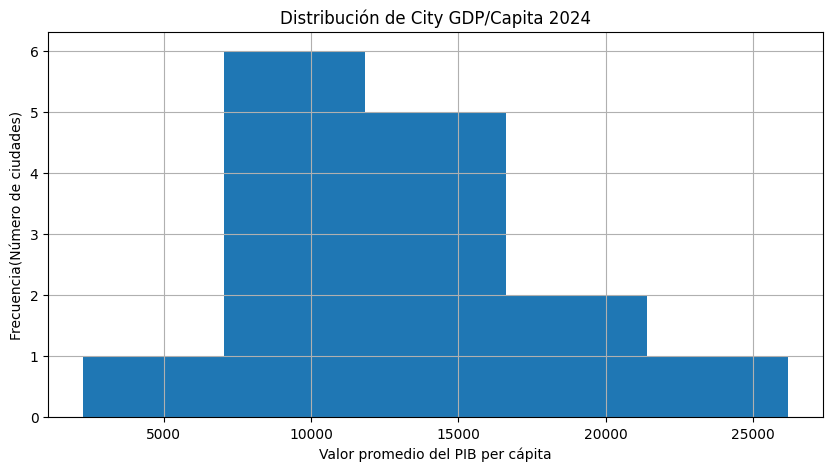

In [ ]:
# Creación histograma para ver la distribución de la economía (city_gdp_capita)
eco_2024_small['city_gdp_capita'].hist(bins=5, figsize=(10,5))
plt.title('Distribución de City GDP/Capita 2024')
plt.xlabel ('Valor promedio del PIB per cápita')
plt.ylabel ('Frecuencia(Número de ciudades)')
plt.show ()



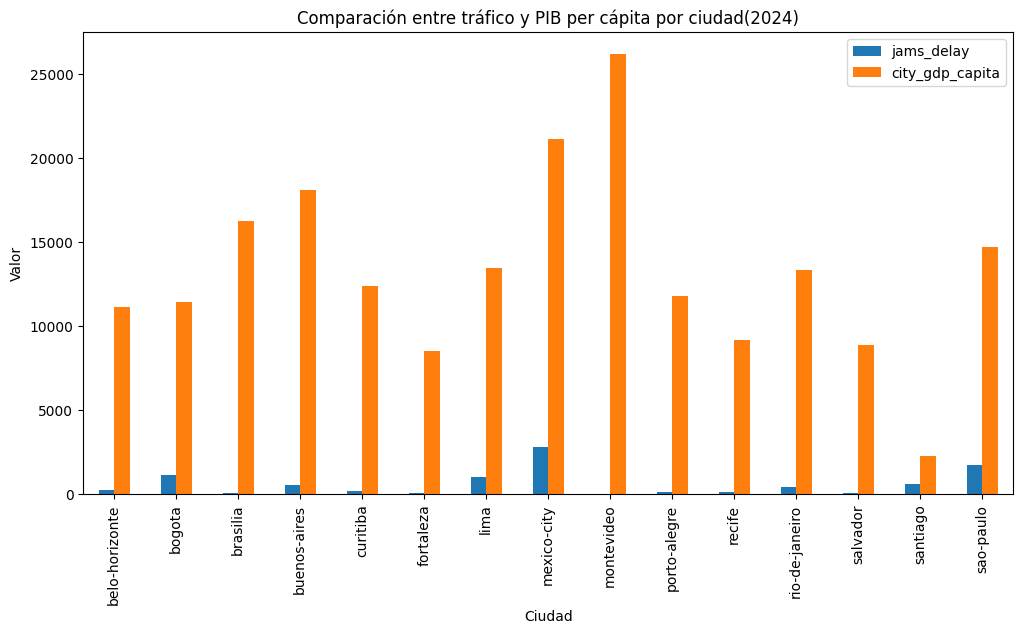

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
df_barras= merged.groupby('city')[['jams_delay','city_gdp_capita']].mean().reset_index()


df_barras.plot( x='city', y=['jams_delay', 'city_gdp_capita'],kind='bar', figsize=(12,6))
plt.title('Comparación entre tráfico y PIB per cápita por ciudad(2024)')
plt.xlabel('Ciudad')
plt.ylabel('Valor')
plt.xticks(rotation=90)
plt.show()

